# Breast Cancer Classification with PCA

## Introduction

**What is the goal of this lab?**

The goal of this lab is to get practice with:
 - Principle Component Analysis (PCA) for data preprocessing before ML
 - Classification evaluation metrics for comparing and evaluting classification models
 - K-fold Cross Validation for validating ML models will work on new data


**Context**


Understanding key concepts like Principal Component Analysis (PCA), classification evaluation metrics, and K-fold cross-validation is essential for effective machine learning. PCA helps in reducing dimensionality, simplifying models, and enhancing performance, particularly with high-dimensional data. Classification evaluation metrics, such as accuracy, precision, recall, and F1-score, are crucial for assessing and comparing model performance, especially in the context of imbalanced datasets. K-fold cross-validation ensures that a model generalizes well to new data by providing a robust estimate of its performance through repeated training and testing on different subsets of the data.




### Data

This lab uses the Breast Cancer Wisconsin (Original) data set 🔬. The goal with this data is to predict whether a tumor is benign or malignant based on various features derived from cell nuclei in breast cancer biopsies.

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
cancer = fetch_ucirepo(name="Breast Cancer Wisconsin (Original)")

In [ ]:
# Get raw data in a pandas.DataFrame format
cancer_df = cancer.data.original

In [ ]:
# Citation
print("Citation:\n", cancer.metadata.additional_info.citation)

Citation:
 This breast cancer databases was obtained from the University of Wisconsin Hospitals, Madison from Dr. William H. Wolberg.  If you publish results when using this database, then please include this information in your acknowledgements.  Also, please cite one or more of:
1. O. L. Mangasarian and W. H. Wolberg: "Cancer diagnosis via linear programming", SIAM News, Volume 23, Number 5, September 1990, pp 1 & 18.
2. William H. Wolberg and O.L. Mangasarian: "Multisurface method of pattern separation for medical diagnosis applied to breast cytology", Proceedings of the National Academy of Sciences, U.S.A., Volume 87, December 1990, pp 9193-9196.
3. O. L. Mangasarian, R. Setiono, and W.H. Wolberg: "Pattern recognition via linear programming: Theory and application to medical diagnosis", in: "Large-scale numerical optimization", Thomas F. Coleman and Yuying Li, editors, SIAM Publications, Philadelphia 1990, pp 22-30.
4. K. P. Bennett & O. L. Mangasarian: "Robust linear programming d

> _Wolberg,WIlliam. (1992). Breast Cancer Wisconsin (Original)._      
> _UCI Machine Learning Repository. https://doi.org/10.24432/C5HP4Z._


In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(cancer.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
print(cancer_df.head())
print(cancer_df.shape)
print(cancer_df.dtypes)
print(cancer_df.isnull().sum())
print(cancer_df.describe())

   Sample_code_number  Clump_thickness  Uniformity_of_cell_size  \
0             1000025                5                        1   
1             1002945                5                        4   
2             1015425                3                        1   
3             1016277                6                        8   
4             1017023                4                        1   

   Uniformity_of_cell_shape  Marginal_adhesion  Single_epithelial_cell_size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

   Bare_nuclei  Bland_chromatin  Normal_nucleoli  Mitoses  Class  
0          1.0                3                1       

### Data cleaning

The column `'Sample_code_number'` is not needed. Drop that column from the DataFrame.

---
**Hints**

- [`pandas.DataFrame.drop()`](https://pandas.pydata.org/pandas-docs/version/2.0/reference/api/pandas.DataFrame.drop.html)

In [ ]:
cancer_df = cancer.data.original
print(cancer_df.columns) #before

print("\n")

cancer_df = cancer_df.drop(columns=['Sample_code_number'])
print(cancer_df.columns) #after

Index(['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses', 'Class'],
      dtype='object')


Index(['Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses', 'Class'],
      dtype='object')


The `'Class'` column of the DataFrame represents the target variable that we want to predict. In the raw data the value `2` = benign and `4` = malignant. For our binary classification we want benign=0 and malignant=1.

In the `'Class'` column replace all the `2` values with `0` and all th `4` values with `1`.

---
**Hints**

- [`pandas.Series.map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)

In [ ]:
cancer = fetch_ucirepo(name="Breast Cancer Wisconsin (Original)")
cancer_df = cancer.data.original

cancer_df['Class'] = cancer_df['Class'].map({2:0 , 4:1})

print(cancer_df['Class'])

0      0
1      0
2      0
3      0
4      0
      ..
694    0
695    0
696    1
697    1
698    1
Name: Class, Length: 699, dtype: int64


The `'Bare_nuclei'` column was the only numeric column that was read as a float type instead of an interger type. This is due to it having some missing values. _The Numpy representation of a missing number `np.nan` is a float type. You can verify this with `isinstance(np.nan, float)`_.

Because there are not very many null values in that column, let's drop the rows with the null values. Then convert the `'Bare_nuclei'` column to be an interger type to be consistent with the rest of the features.

---
**Hints**

_Dropping NA rows_
- [`pandas.DataFrame.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)

_Convert column data type_
- [`pandas.Series.astype()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html)


In [ ]:
cancer = fetch_ucirepo(name="Breast Cancer Wisconsin (Original)")
cancer_df = cancer.data.original

# print(cancer_df['Bare_nuclei'].head(25)) #before

print(cancer_df['Bare_nuclei'].dtype)
cancer_df.dropna(subset=["Bare_nuclei"],inplace=True)
cancer_df['Bare_nuclei'] = cancer_df['Bare_nuclei'].astype(int)




print(cancer_df['Bare_nuclei'].head(25)) #look row #23

float64
0      1
1     10
2      2
3      4
4      1
5     10
6     10
7      1
8      1
9      1
10     1
11     1
12     3
13     3
14     9
15     1
16     1
17     1
18    10
19     1
20    10
21     7
22     1
24     1
25     7
Name: Bare_nuclei, dtype: int64


### Data Visualization and Statistics

Split the full training data set into training and testing sets. Then separate the feature variables from the target variable `'Class'` that we are trying to predict.

Use the following standard naming conventions for those sections of your data:
- `train_df` - subset of data for model training
- `test_df` - subset of data held out for model evaluation on "new" data
- `X_train` - the features (independent variables) of the training data
- `X_test` - the features (independent variables) of the testing data
- `y_train` - the target (dependent variable) of the training data
- `y_test` - the target (dependent variable) of the testing data

---
**Hints**
- [`sklearn.model_selection.train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


In [ ]:

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(cancer_df, test_size=0.30, random_state=42, stratify=cancer_df["Class"])


X_train = train_df.drop("Class", axis=1)
y_train = train_df["Class"]

X_test = test_df.drop("Class", axis=1)
y_test = test_df["Class"]


Plot the distribution of each numeric feature variable for each class (benign or malignant), and a scatter plot between each pair of numeric variables.

---
**Hints**
- [`seaborn.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
    - Set the argument `hue="Class"`

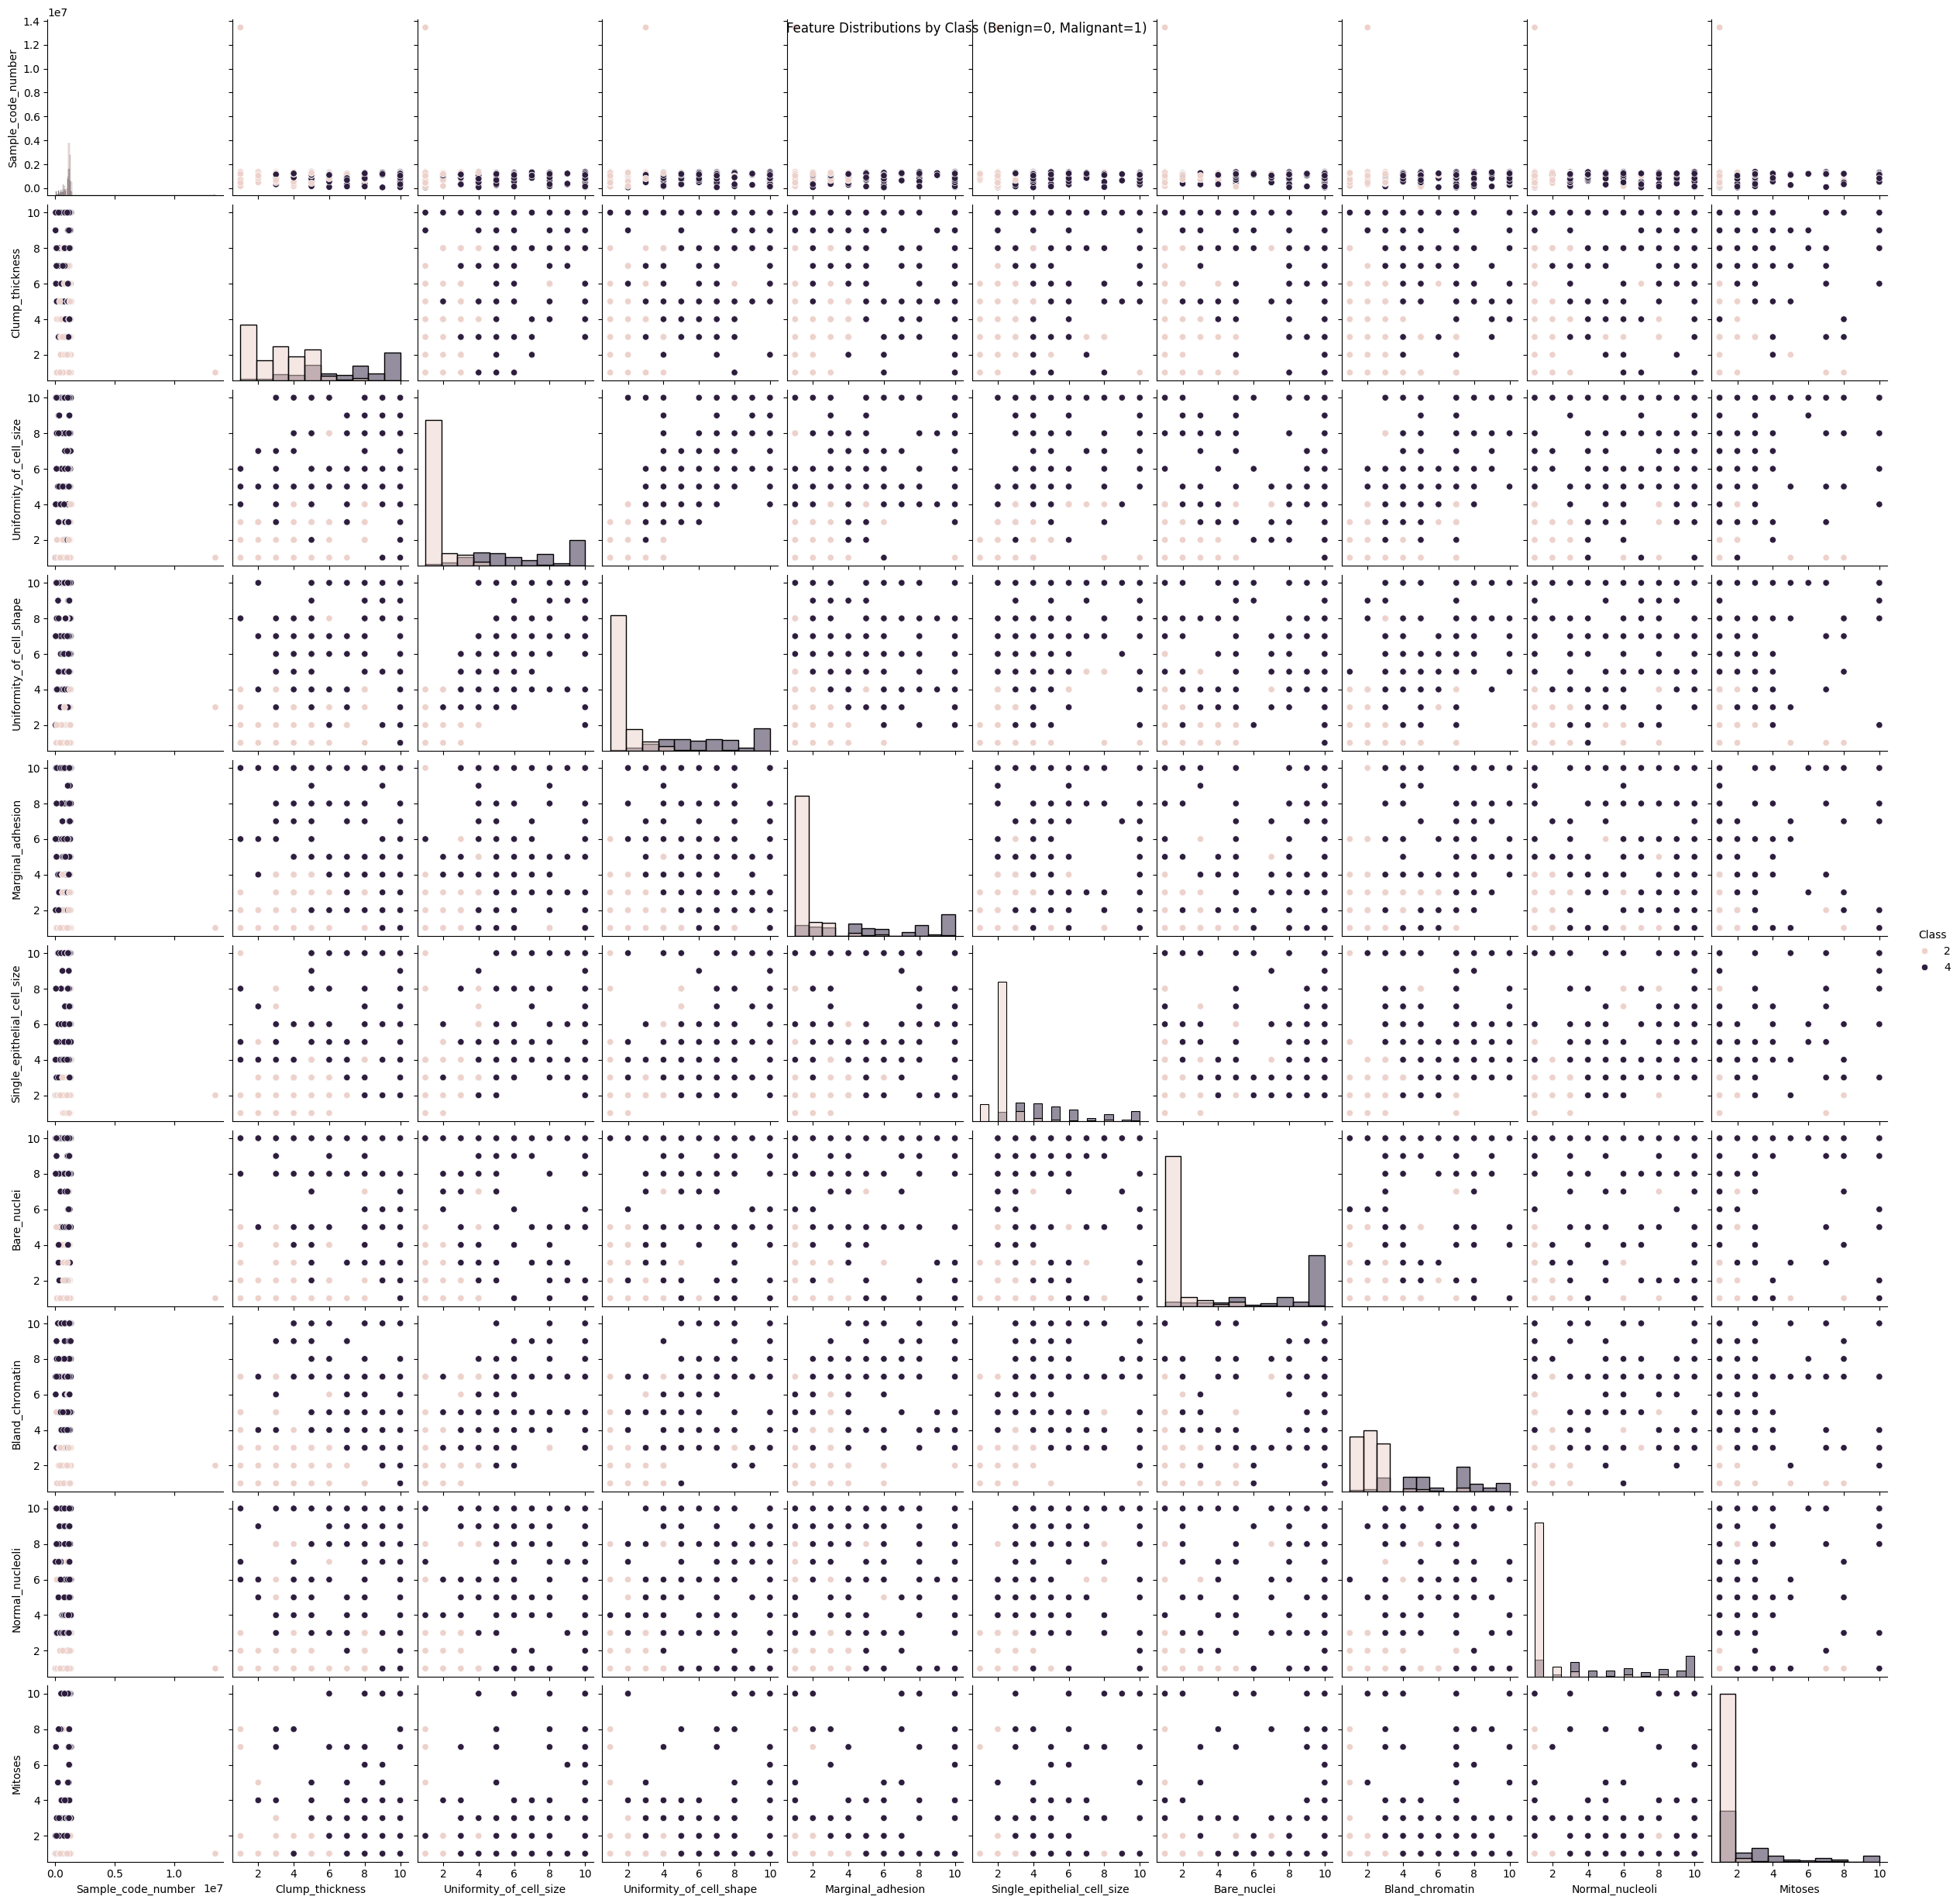

In [ ]:

sns.pairplot(train_df, hue="Class",diag_kind="hist")
plt.suptitle("Feature Distributions by Class (Benign=0, Malignant=1)")
plt.show()


Perform and ANOVA test for each of the feature variables with the categorical `'Class'` variable (similar to Lab 3). Pick the features with the highest 3 F-statistics and save them into a separate data frame.

---
**Hints**

_From Lab 3_
- [`statsmodles.formula.api.ols()`](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html#statsmodels.formula.api.ols)
- [`statsmodels.api.stats.anova_lm()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html)

_Other possible methods_

- [`scipy.stats.f_oneway()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)
- [`sklearn.feature_selection.f_classif()`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html)



In [ ]:
from sklearn.feature_selection import f_classif

X = train_df.drop("Class", axis=1)
y = train_df["Class"]

# ANOVA F-test
F_values, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": X.columns,
    "F_value": F_values
    })

# Sort by highest 3 F-statistics
top3_features = anova_df.sort_values(by="F_value", ascending=False).head(3)
print(top3_features)

# Save top 3
top3_df = train_df[top3_features["Feature"].tolist() + ["Class"]]
top3_df.head()


                    Feature      F_value
6               Bare_nuclei  1257.769196
3  Uniformity_of_cell_shape  1095.148428
2   Uniformity_of_cell_size  1017.405055


,Bare_nuclei,Uniformity_of_cell_shape,Uniformity_of_cell_size,Class
202,1,1,1,2
676,1,2,1,2
301,1,1,1,2
595,1,1,1,2
489,4,2,3,4


Perform a Principal Component Analysis (PCA) on the _training data_, keeping the first 3 principal components. Create a new DataFrame that includes these principal components and the original `'Class'` variable. Then, generate a seaborn pairplot to visualize the relationship between the principal components, with the `'Class'` variable as the hue.

---

**Hints**

- [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [`sns.pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
    - Set the argument `hue="Class"`



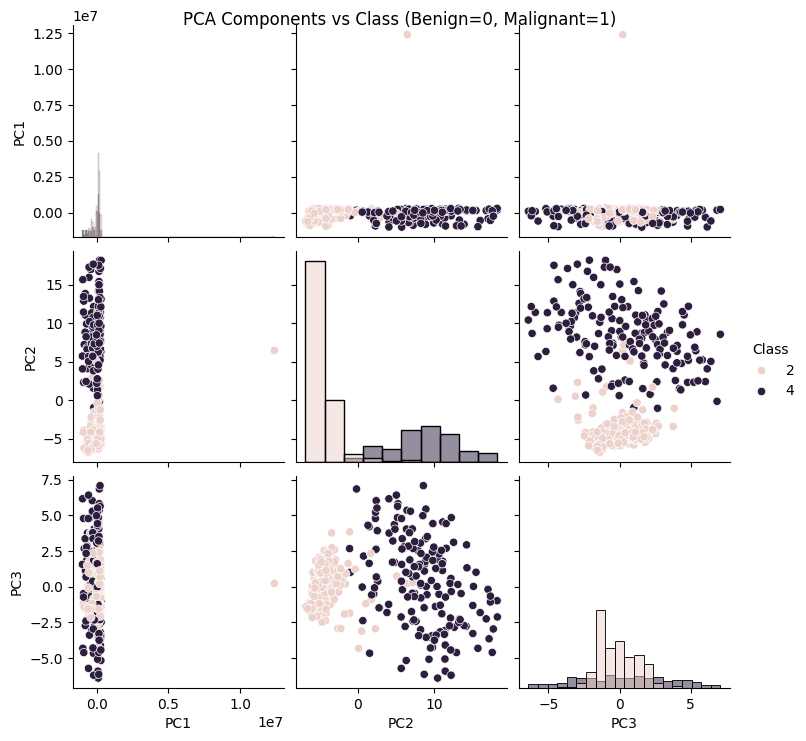

In [ ]:
from sklearn.decomposition import PCA

X = train_df.drop("Class", axis=1)
y = train_df["Class"]

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

# DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["Class"] = y.values

sns.pairplot(pca_df, hue="Class", diag_kind="hist")
plt.suptitle("PCA Components vs Class (Benign=0, Malignant=1)")
plt.show()


## Models

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

Evaluate the performance of three classifiers: K-Nearest Neighbors (K-NN), Multi-Layer Perceptron (MLP), and Support Vector Classifier (SVC) on both the data sets. First with top 3 features selected through ANOVA, and second with the 3 principal components obtained from PCA. Perform 10-fold cross-validation on both feature sets and print out the average F1 scores of each classifier.

---

**Hints**

- [`sklearn.model_selection.cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
- [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [`sklearn.neural_network.MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [`sklearn.svm.SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import train_test_split

cancer_df = cancer_df.dropna(subset=["Class"])

cancer_df['Class'] = cancer_df['Class'].map({2: 0, 4: 1})
train_df, test_df = train_test_split(cancer_df, test_size=0.2, random_state=42, stratify=cancer_df["Class"])

X_train = train_df.drop("Class", axis=1)
y_train = train_df["Class"].astype(int)

X_test = test_df.drop("Class", axis=1)
y_test = test_df["Class"].astype(int)


y_train = y_train.astype(int)
y_test = y_test.astype(int)

# 3️⃣ Get top 3 ANOVA features
top3_features = anova_df.sort_values(by="F_value", ascending=False).head(3)
top3_cols = top3_features["Feature"].tolist()

X_train_top3 = train_df[top3_cols]

classifiers = [KNeighborsClassifier(), MLPClassifier(max_iter=500), SVC()]
names = ["KNN", "MLP", "SVC"]
f1_scorer = make_scorer(f1_score)

# print top3 features
for name, clf in zip(names, classifiers):
    scores = cross_val_score(clf, X_train_top3, y_train, cv=10, scoring=f1_scorer)
    print(name, "Average F1-score:", round(scores.mean(), 3))


KNN Average F1-score: 0.945
MLP Average F1-score: 0.935
SVC Average F1-score: 0.936


Identify the model and feature set (either the top 3 ANOVA-selected features or the PCA components) that yielded the best average F1-score from the cross-validation. Retrain this model on the entire _training set_ using the selected feature set, and then evaluate its performance on the test data. Print out the confusion matrix and the classification report for the test set.

---

**Hints**

- [`sklearn.metrics.confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)


---

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier


X_train_best = X_train_top3
X_test_best = X_test[top3_cols]


best_model = KNeighborsClassifier()
best_model.fit(X_train_best, y_train)

# Predict
y_pred = best_model.predict(X_test_best)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"]))


Confusion Matrix:
[[85  4]
 [ 2 46]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.98      0.96      0.97        89
Malignant (1)       0.92      0.96      0.94        48

     accuracy                           0.96       137
    macro avg       0.95      0.96      0.95       137
 weighted avg       0.96      0.96      0.96       137



## Conclusion

**How many malignant vs. benign samples are there in the data set? With this class imbalance which classification performance metric would be the most important to consider if you wanted to minimize the chance of classifying a malignant (positive class) sample as benign (negative class)?**

*There are 89 benign and 48 malignant samples in dataset. The most important metric is recall for the malignant class which measures how many actual malignant cases are correct, thus reducing the chance of missing a dangerous tumor.*


**Which training data set worked better: The best 3 raw features or the 3 principle component analysis? Compare across each of the 3 classification algorithms.**

*The top 3 features from ANOVA (Bare_nuclei, Uniformity_of_cell_shape, Uniformity_of_cell_size) gave better F1 scores (KNN: 0.945, MLP: 0.935, and  SVC: 0.936) than the 3 PCA. So, the raw features worked a little better than PCA.*

**Compare the final model's performance on the cross validation to the performance on the test set. Are those performance metrics close? Explain if you expect this model to continue to have this type of performance on new data or not.**

*The cross validation F1 scores were around
0.94 and the test gave an average F1-score of 0.96, which is really close. This shows the model is performing well and does not overfit.*


**What would be the next steps would you try to continue improving the models? (other data preprocessing techniques, different algorithms, etc.)**

*I would try to scaling the features, maybe tuning model hyperparameters, and testing other algorithms like Random Forest for improving model.*
